In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.features.url_features import featureExtraction

print("Import successful!")
print(PROJECT_ROOT)

Tranco domains loaded: 4384729
Import successful!
c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x


In [9]:
from src.features.url_features import featureExtraction
import pandas as pd

url = "https://www.google.com"

features = featureExtraction(url, 0)

all_features = [
    "Domain",
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards",
    "Label"
]

google_features = pd.DataFrame(
    [features],
    columns=all_features
)

google_features.T

,0
Domain,google.com
Have_IP,0
Have_At,0
URL_Length,0
URL_Depth,0
Redirection,0
https_Domain,0
TinyURL,0
Prefix/Suffix,0
DNS_Record,0


In [10]:
FINAL_FILE = PROJECT_ROOT / "data" / "processed" / "phishguard_features.csv"

df = pd.read_csv(FINAL_FILE)

print("Legitimate URLs with URL_Length = 0:")
print(
    ((df["Label"] == 0) & (df["URL_Length"] == 0)).sum()
)

print("\nPhishing URLs with URL_Length = 0:")
print(
    ((df["Label"] == 1) & (df["URL_Length"] == 0)).sum()
)

print("\nContingency table:")
print(
    pd.crosstab(
        df["Label"],
        df["URL_Length"]
    )
)

Legitimate URLs with URL_Length = 0:
0

Phishing URLs with URL_Length = 0:
3757

Contingency table:
URL_Length     0     1
Label                 
0              0  5000
1           3757  1243


In [11]:
features_to_check = [
    "URL_Length",
    "URL_Depth",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Right_Click",
    "Web_Traffic"
]

for feature in features_to_check:
    print(f"\n===== {feature} =====")
    print(
        df.groupby("Label")[feature]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .round(4)
    )


===== URL_Length =====
URL_Length       0       1
Label                     
0           0.0000  1.0000
1           0.7514  0.2486

===== URL_Depth =====
URL_Depth      0       1       2       3       4       5       6       7   \
Label                                                                       
0          0.0038  0.1266  0.2708  0.2390  0.1766  0.0714  0.0478  0.0246   
1          0.4072  0.3750  0.0736  0.0442  0.0322  0.0652  0.0010  0.0004   

URL_Depth      8       9       10      11     14      16      17      28  
Label                                                                     
0          0.0054  0.0038  0.0256  0.0002  0.004  0.0002  0.0002  0.0000  
1          0.0002  0.0002  0.0002  0.0002  0.000  0.0000  0.0002  0.0002  

===== Domain_Age =====
Domain_Age      0      1
Label                   
0           0.817  0.183
1           0.492  0.508

===== Domain_End =====
Domain_End       0       1
Label                     
0           0.2520  0.7480
1      

In [12]:
legit_raw = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "1.Benign_list_big_final.csv",
    header=None,
    names=["URL"]
)

print("Total legitimate raw URLs:", len(legit_raw))

print("\nRaw URL length statistics:")
print(legit_raw["URL"].str.len().describe())

print("\nURLs with length < 54:")
print((legit_raw["URL"].str.len() < 54).sum())

print("\nURLs with length < 70:")
print((legit_raw["URL"].str.len() < 70).sum())

print("\nURLs with length < 83:")
print((legit_raw["URL"].str.len() < 83).sum())

Total legitimate raw URLs: 35378

Raw URL length statistics:
count    35378.000000
mean       115.007010
std         47.931594
min         83.000000
25%         90.000000
50%        101.000000
75%        120.000000
max       2081.000000
Name: URL, dtype: float64

URLs with length < 54:
0

URLs with length < 70:
0

URLs with length < 83:
0


In [13]:
print(legit_raw.head(20).to_string(index=False))

                                                                                URL
http://1337x.to/torrent/1048648/American-Sniper-2014-MD-iTALiAN-DVDSCR-X264-BST-MT/
http://1337x.to/torrent/1110018/Blackhat-2015-RUSSIAN-720p-WEB-DL-DD5-1-H264-RUFGT/
http://1337x.to/torrent/1122940/Blackhat-2015-x264-1080p-WEB-DL-eng-nl-subs-sharky/
http://1337x.to/torrent/1124395/Fast-and-Furious-7-2015-HD-TS-XVID-AC3-HQ-Hive-CM8/
http://1337x.to/torrent/1145504/Avengers-Age-of-Ultron-2015-CAM-New-Audio-x264-CPG/
http://1337x.to/torrent/1160078/Avengers-age-of-Ultron-2015-HQ-CAM-H264-AC3-MURD3R/
http://1337x.to/torrent/294349/American-Idol-S11E04-Auditions-4-HDTV-XviD-FQM-ettv/
http://189.cn/dqmh/userCenter/myOrderInfoList.do?method=listMyOrderInfo_new&isVs=no
http://2gis.ru/moscow/search/%D0%9F%D0%BE%D0%B5%D1%81%D1%82%D1%8C/tab/firms/zoom/11
http://abc.go.com/shows/general-hospital/episode-guide/2015-05/08-friday-may-8-2015
http://abc.go.com/shows/the-muppets/video/new-abc-comedy-trailers?cid=abchp_

In [14]:
from urllib.parse import urlparse

legit_raw["Domain"] = legit_raw["URL"].apply(
    lambda x: urlparse(x).netloc.lower().replace("www.", "")
)

print("Total unique legitimate domains:")
print(legit_raw["Domain"].nunique())

print("\nTop 20 domains:")
print(legit_raw["Domain"].value_counts().head(20))

Total unique legitimate domains:
310

Top 20 domains:
Domain
torcache.net         1367
thenextweb.com       1048
distractify.com       960
extratorrent.cc       869
babal.net             805
twitter.com           755
mic.com               667
tobogo.net            619
motthegioi.vn         576
kenh14.vn             555
otomoto.pl            536
emgn.com              512
censor.net.ua         489
correios.com.br       473
indianexpress.com     468
udn.com               464
techcrunch.com        435
mylust.com            430
sourceforge.net       424
interpark.com         421
Name: count, dtype: int64


In [15]:
legit_features = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "legitimate_features.csv"
)

print("Unique domains in selected 5000 legitimate URLs:")
print(legit_features["Domain"].nunique())

print("\nTop 20 domains in selected 5000:")
print(
    legit_features["Domain"]
    .value_counts()
    .head(20)
)

Unique domains in selected 5000 legitimate URLs:
245

Top 20 domains in selected 5000:
Domain
torcache.net         202
thenextweb.com       144
distractify.com      138
extratorrent.cc      122
twitter.com          111
mic.com               93
tobogo.net            92
otomoto.pl            87
motthegioi.vn         87
censor.net.ua         83
babal.net             82
emgn.com              71
udn.com               69
indianexpress.com     68
interpark.com         67
sourceforge.net       65
kenh14.vn             64
correios.com.br       63
mylust.com            62
web.de                61
Name: count, dtype: int64


In [16]:
legit_raw["URL_Length_Raw"] = legit_raw["URL"].str.len()

print("URL length distribution:")
print(
    legit_raw["URL_Length_Raw"]
    .describe()
)

print("\nURLs by length range:")
print(
    pd.cut(
        legit_raw["URL_Length_Raw"],
        bins=[0, 53, 70, 82, 100, 150, 300, float("inf")],
        labels=[
            "<54",
            "54-70",
            "71-82",
            "83-100",
            "101-150",
            "151-300",
            ">300"
        ]
    ).value_counts().sort_index()
)

URL length distribution:
count    35378.000000
mean       115.007010
std         47.931594
min         83.000000
25%         90.000000
50%        101.000000
75%        120.000000
max       2081.000000
Name: URL_Length_Raw, dtype: float64

URLs by length range:
URL_Length_Raw
<54            0
54-70          0
71-82          0
83-100     17116
101-150    14498
151-300     3290
>300         474
Name: count, dtype: int64


In [17]:
domain_counts = legit_raw["Domain"].value_counts()

print("Total unique domains:", len(domain_counts))

print("\nDomains with at least 100 URLs:")
print((domain_counts >= 100).sum())

print("\nDomains with at least 50 URLs:")
print((domain_counts >= 50).sum())

print("\nDomains with at least 20 URLs:")
print((domain_counts >= 20).sum())

print("\nMaximum URLs from one domain:")
print(domain_counts.max())

print("\nMedian URLs per domain:")
print(domain_counts.median())

Total unique domains: 310

Domains with at least 100 URLs:
104

Domains with at least 50 URLs:
149

Domains with at least 20 URLs:
188

Maximum URLs from one domain:
1367

Median URLs per domain:
43.0


In [18]:
PHISH_FILE = PROJECT_ROOT / "data" / "processed" / "phishing_features.csv"

phish_features = pd.read_csv(PHISH_FILE)

print("Phishing URL length distribution:")

print(
    phish_features["URL_Length"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nPhishing URL_Length counts:")

print(
    phish_features["URL_Length"]
    .value_counts()
    .sort_index()
)

Phishing URL length distribution:
URL_Length
0    0.7514
1    0.2486
Name: proportion, dtype: float64

Phishing URL_Length counts:
URL_Length
0    3757
1    1243
Name: count, dtype: int64


In [19]:
phish_features = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "phishing_features.csv"
)

print("Unique phishing domains:")
print(phish_features["Domain"].nunique())

print("\nTop 20 phishing domains:")
print(
    phish_features["Domain"]
    .value_counts()
    .head(20)
)

Unique phishing domains:
3199

Top 20 phishing domains:
Domain
docs.google.com          385
qrco.de                  319
l.ead.me                 215
q-r.to                   209
bit.ly                   108
sites.google.com          83
new.express.adobe.com     66
dropbox.com               46
l.wl.co                   34
tinyurl.com               19
ipfs.best-practice.se     18
eu.jotform.com            16
qr-codes.io               15
t.co                      14
did.li                    14
share-eu1.hsforms.com     12
app.jotform.com           11
ln.run                    10
flow.page                  9
google.com                 9
Name: count, dtype: int64


URL_Length      0       1
Label                    
0            0.00  100.00
1           75.14   24.86


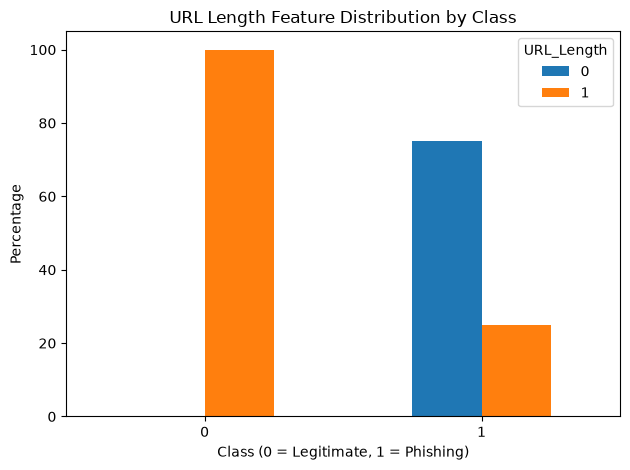

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "phishguard_features.csv"
)

length_by_class = pd.crosstab(
    df["Label"],
    df["URL_Length"],
    normalize="index"
) * 100

print(length_by_class.round(2))

length_by_class.plot(kind="bar")

plt.xlabel("Class (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Percentage")
plt.title("URL Length Feature Distribution by Class")
plt.xticks(rotation=0)
plt.legend(title="URL_Length")
plt.tight_layout()
plt.show()

In [21]:
tranco_file = PROJECT_ROOT / "data" / "raw" / "tranco_GQJ9K.csv"

tranco = pd.read_csv(
    tranco_file,
    header=None,
    names=["Rank", "Domain"]
)

tranco["Domain"] = (
    tranco["Domain"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"^www\.", "", regex=True)
)

tranco["Root_URL"] = "https://" + tranco["Domain"]

tranco["URL_Length"] = tranco["Root_URL"].str.len()

print("Total Tranco domains:", len(tranco))

print("\nRoot URLs with URL_Length < 54:")
print((tranco["URL_Length"] < 54).sum())

print("\nRoot URL length distribution:")
print(
    pd.cut(
        tranco["URL_Length"],
        bins=[0, 53, 70, 82, 100, 150, float("inf")],
        labels=[
            "<54",
            "54-70",
            "71-82",
            "83-100",
            "101-150",
            ">150"
        ]
    ).value_counts().sort_index()
)

Total Tranco domains: 4384729

Root URLs with URL_Length < 54:
4383786

Root URL length distribution:
URL_Length
<54        4383786
54-70          730
71-82          213
83-100           0
101-150          0
>150             0
Name: count, dtype: int64


In [22]:
existing_legit_domains = set(
    legit_raw["Domain"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.replace(r"^www\.", "", regex=True)
)

tranco_candidates = tranco[
    ~tranco["Domain"].isin(existing_legit_domains)
].copy()

tranco_candidates = (
    tranco_candidates
    .sort_values("Rank")
    .drop_duplicates("Domain")
    .head(10000)
    .reset_index(drop=True)
)

print("Existing legitimate domains:", len(existing_legit_domains))
print("Candidate Tranco domains:", len(tranco_candidates))

print("\nFirst 20 candidates:")
print(
    tranco_candidates[["Rank", "Domain", "Root_URL", "URL_Length"]]
    .head(20)
    .to_string(index=False)
)

print("\nCandidate URL length distribution:")
print(
    pd.cut(
        tranco_candidates["URL_Length"],
        bins=[0, 53, 70, 82, 100],
        labels=["<54", "54-70", "71-82", "83-100"]
    )
    .value_counts()
    .sort_index()
)

Existing legitimate domains: 310
Candidate Tranco domains: 10000

First 20 candidates:
 Rank               Domain                     Root_URL  URL_Length
    1           google.com           https://google.com          18
    2       cloudflare.com       https://cloudflare.com          22
    3         facebook.com         https://facebook.com          20
    4          gstatic.com          https://gstatic.com          19
    5       googleapis.com       https://googleapis.com          22
    6        microsoft.com        https://microsoft.com          21
    7        amazonaws.com        https://amazonaws.com          21
    8           akamai.net           https://akamai.net          18
    9          youtube.com          https://youtube.com          19
   10            apple.com            https://apple.com          17
   12              mail.ru              https://mail.ru          15
   13           ezviz7.com           https://ezviz7.com          18
   14            fbcdn.net   

In [23]:
selected_tranco = tranco_candidates.head(1000).copy()

existing_legit_domains = set(
    legit_raw["Domain"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.replace(r"^www\.", "", regex=True)
)

overlap = selected_tranco[
    selected_tranco["Domain"].isin(existing_legit_domains)
]

print("Selected Tranco candidates:", len(selected_tranco))
print("Overlap with original legitimate domains:", len(overlap))

print("\nUnique selected domains:")
print(selected_tranco["Domain"].nunique())

print("\nURL length:")
print(selected_tranco["URL_Length"].describe())

Selected Tranco candidates: 1000
Overlap with original legitimate domains: 0

Unique selected domains:
1000

URL length:
count    1000.000000
mean       19.422000
std         3.469864
min        12.000000
25%        17.000000
50%        19.000000
75%        21.000000
max        36.000000
Name: URL_Length, dtype: float64


In [24]:
# Domain-balanced sampling: round-robin across domains

import pandas as pd

domain_groups = {
    domain: group.sample(frac=1, random_state=42).reset_index(drop=True)
    for domain, group in legit_raw.groupby("Domain")
}

selected_rows = []
round_number = 0

while len(selected_rows) < 4000:
    added_this_round = 0

    for domain in sorted(domain_groups.keys()):
        group = domain_groups[domain]

        if round_number < len(group):
            selected_rows.append(group.iloc[round_number])
            added_this_round += 1

            if len(selected_rows) == 4000:
                break

    if added_this_round == 0:
        break

    round_number += 1

legit_old_4000 = pd.DataFrame(selected_rows).reset_index(drop=True)

print("Selected original legitimate URLs:", len(legit_old_4000))
print("Unique domains:", legit_old_4000["Domain"].nunique())

print("\nMaximum URLs from one domain:")
print(legit_old_4000["Domain"].value_counts().max())

print("\nMinimum URLs from one domain:")
print(legit_old_4000["Domain"].value_counts().min())

print("\nURL length statistics:")
print(legit_old_4000["URL"].str.len().describe())

Selected original legitimate URLs: 4000
Unique domains: 310

Maximum URLs from one domain:
18

Minimum URLs from one domain:
1

URL length statistics:
count    4000.000000
mean      109.461250
std        59.799561
min        83.000000
25%        88.000000
50%        96.000000
75%       112.000000
max      2081.000000
Name: URL, dtype: float64


In [25]:
legit_new_1000 = tranco_candidates.head(1000)[["Domain", "Root_URL"]].copy()

legit_new_1000 = legit_new_1000.rename(
    columns={"Root_URL": "URL"}
)

legit_new_1000 = legit_new_1000[["URL", "Domain"]]

improved_legit_raw = pd.concat(
    [
        legit_old_4000[["URL", "Domain"]],
        legit_new_1000
    ],
    ignore_index=True
)

print("Total improved legitimate URLs:", len(improved_legit_raw))
print("Unique domains:", improved_legit_raw["Domain"].nunique())

print("\nURL length distribution:")
print(
    pd.cut(
        improved_legit_raw["URL"].str.len(),
        bins=[0, 53, 70, 82, 100, 150, 300, float("inf")],
        labels=[
            "<54",
            "54-70",
            "71-82",
            "83-100",
            "101-150",
            "151-300",
            ">300"
        ]
    ).value_counts().sort_index()
)

print("\nURLs with length <54:")
print((improved_legit_raw["URL"].str.len() < 54).sum())

Total improved legitimate URLs: 5000
Unique domains: 1310

URL length distribution:
URL
<54        1000
54-70         0
71-82         0
83-100     2329
101-150    1357
151-300     288
>300         26
Name: count, dtype: int64

URLs with length <54:
1000


In [26]:
print("Total rows:", len(improved_legit_raw))

print("Unique URLs:", improved_legit_raw["URL"].nunique())

print("Duplicate URLs:", improved_legit_raw["URL"].duplicated().sum())

print("Unique domains:", improved_legit_raw["Domain"].nunique())

print("Missing URLs:", improved_legit_raw["URL"].isna().sum())
print("Missing domains:", improved_legit_raw["Domain"].isna().sum())

print("\nURL length <54:", (improved_legit_raw["URL"].str.len() < 54).sum())

print("\nFirst 10 rows:")
print(improved_legit_raw.head(10))

Total rows: 5000
Unique URLs: 5000
Duplicate URLs: 0
Unique domains: 1310
Missing URLs: 0
Missing domains: 0

URL length <54: 1000

First 10 rows:
                                                 URL                 Domain
0  http://1337x.to/torrent/1154311/Battle-For-Sky...               1337x.to
1  http://189.cn/dqmh/userCenter/myOrderInfoList....                 189.cn
2  http://2gis.ru/moscow/search/%D0%93%D0%BE%D1%8...                2gis.ru
3  https://500px.com/photo/13311139/rojo-pasi%C3%...              500px.com
4  http://9gag.tv/p/a9arrN/watching-these-guys-tr...                9gag.tv
5  http://abc.go.com/shows/shows/movies-and-speci...             abc.go.com
6  http://abcnews.go.com/US/wireStory/regulators-...         abcnews.go.com
7  http://adultfriendfinder.com/css/live_cd/ffadu...  adultfriendfinder.com
8  https://ahrefs.com/content-explorer/overview/v...             ahrefs.com
9  http://akhbarelyom.com/news/newdetails/411409/...        akhbarelyom.com


In [27]:
IMPROVED_LEGIT_RAW_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "improved_legitimate_raw.csv"
)

improved_legit_raw.to_csv(
    IMPROVED_LEGIT_RAW_FILE,
    index=False
)

print("Saved:", IMPROVED_LEGIT_RAW_FILE)
print("Shape:", improved_legit_raw.shape)

Saved: c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\processed\improved_legitimate_raw.csv
Shape: (5000, 2)


In [28]:
# Reload improved legitimate dataset

improved_legit_check = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "improved_legitimate_raw.csv"
)

print("Shape:", improved_legit_check.shape)
print("Columns:", improved_legit_check.columns.tolist())
print("Unique URLs:", improved_legit_check["URL"].nunique())
print("Duplicate URLs:", improved_legit_check["URL"].duplicated().sum())
print("Missing values:", improved_legit_check.isna().sum().sum())
print("Short URLs (<54):", (improved_legit_check["URL"].str.len() < 54).sum())

Shape: (5000, 2)
Columns: ['URL', 'Domain']
Unique URLs: 5000
Duplicate URLs: 0
Missing values: 0
Short URLs (<54): 1000


In [29]:
# Check domain overlap between old legitimate URLs and Tranco augmentation

old_domains = set(
    legit_old_4000["Domain"]
    .astype(str)
    .str.lower()
    .str.replace(r"^www\.", "", regex=True)
)

tranco_domains = set(
    legit_new_1000["Domain"]
    .astype(str)
    .str.lower()
    .str.replace(r"^www\.", "", regex=True)
)

overlap_domains = old_domains.intersection(tranco_domains)

print("Old legitimate unique domains:", len(old_domains))
print("Tranco augmentation unique domains:", len(tranco_domains))
print("Domain overlap:", len(overlap_domains))

if overlap_domains:
    print("\nOverlapping domains:")
    print(sorted(overlap_domains)[:20])
else:
    print("\nNo domain overlap found. ✅")

Old legitimate unique domains: 310
Tranco augmentation unique domains: 1000
Domain overlap: 0

No domain overlap found. ✅


In [30]:
# Validate selected Tranco root URLs

print("Selected Tranco rows:", len(legit_new_1000))
print("Unique Tranco domains:", legit_new_1000["Domain"].nunique())

print("\nMissing values:")
print(legit_new_1000.isna().sum())

print("\nEmpty domains:",
      (legit_new_1000["Domain"].astype(str).str.strip() == "").sum())

print("\nURL format check:")
print(
    legit_new_1000["URL"]
    .head(10)
    .to_string(index=False)
)

print("\nDomain length:")
print(legit_new_1000["Domain"].str.len().describe())

Selected Tranco rows: 1000
Unique Tranco domains: 1000

Missing values:
URL       0
Domain    0
dtype: int64

Empty domains: 0

URL format check:
    https://google.com
https://cloudflare.com
  https://facebook.com
   https://gstatic.com
https://googleapis.com
 https://microsoft.com
 https://amazonaws.com
    https://akamai.net
   https://youtube.com
     https://apple.com

Domain length:
count    1000.000000
mean       11.422000
std         3.469864
min         4.000000
25%         9.000000
50%        11.000000
75%        13.000000
max        28.000000
Name: Domain, dtype: float64


In [31]:
# Final audit of improved legitimate dataset

print("===== FINAL AUGMENTED LEGITIMATE DATA AUDIT =====")

print("Rows:", len(improved_legit_raw))
print("Columns:", improved_legit_raw.columns.tolist())
print("Unique URLs:", improved_legit_raw["URL"].nunique())
print("Duplicate URLs:", improved_legit_raw["URL"].duplicated().sum())
print("Unique domains:", improved_legit_raw["Domain"].nunique())
print("Missing values:", improved_legit_raw.isna().sum().sum())

short_count = (
    improved_legit_raw["URL"].str.len() < 54
).sum()

print("Short URLs (<54):", short_count)
print("Long/path URLs (>=54):", len(improved_legit_raw) - short_count)

print("\n===== SOURCE COMPOSITION =====")
print("Old legitimate URLs:", len(legit_old_4000))
print("Tranco root URLs:", len(legit_new_1000))
print("Total:", len(legit_old_4000) + len(legit_new_1000))

print("\n===== DOMAIN OVERLAP =====")
print("Old ↔ Tranco overlap:", len(overlap_domains))

===== FINAL AUGMENTED LEGITIMATE DATA AUDIT =====
Rows: 5000
Columns: ['URL', 'Domain']
Unique URLs: 5000
Duplicate URLs: 0
Unique domains: 1310
Missing values: 0
Short URLs (<54): 1000
Long/path URLs (>=54): 4000

===== SOURCE COMPOSITION =====
Old legitimate URLs: 4000
Tranco root URLs: 1000
Total: 5000

===== DOMAIN OVERLAP =====
Old ↔ Tranco overlap: 0


In [32]:
# Record augmentation methodology

augmentation_summary = {
    "original_legitimate_urls": 4000,
    "tranco_root_urls": 1000,
    "total_legitimate_urls": 5000,
    "unique_urls": improved_legit_raw["URL"].nunique(),
    "unique_domains": improved_legit_raw["Domain"].nunique(),
    "short_urls_below_54": (
        improved_legit_raw["URL"].str.len() < 54
    ).sum(),
    "domain_overlap_old_vs_tranco": len(overlap_domains),
}

for key, value in augmentation_summary.items():
    print(f"{key}: {value}")

original_legitimate_urls: 4000
tranco_root_urls: 1000
total_legitimate_urls: 5000
unique_urls: 5000
unique_domains: 1310
short_urls_below_54: 1000
domain_overlap_old_vs_tranco: 0


In [33]:
# Test feature extraction on augmented legitimate URLs

from src.features.url_features import featureExtraction

test_augmented = improved_legit_raw.head(5).copy()

for _, row in test_augmented.iterrows():
    url = row["URL"]

    try:
        features = featureExtraction(url, 0)

        print("\nURL:", url)
        print("Feature count:", len(features))
        print("Extracted:", features)

    except Exception as e:
        print("\nURL:", url)
        print("ERROR:", type(e).__name__, str(e))


URL: http://1337x.to/torrent/1154311/Battle-For-Skyark-2015-English-Movies-DVDRip-XviD-AAC-with-Sample-rDX/
Feature count: 18
Extracted: ['1337x.to', 0, 0, 1, 3, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0]

URL: http://189.cn/dqmh/userCenter/myOrderInfoList.do?method=listMyOrderInfo_new&isVs=no
Feature count: 18
Extracted: ['189.cn', 0, 0, 1, 3, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0]

URL: http://2gis.ru/moscow/search/%D0%93%D0%BE%D1%81%D1%82%D0%B8%D0%BD%D0%B8%D1%86%D1%8B/zoom/11
Feature count: 18
Extracted: ['2gis.ru', 0, 0, 1, 5, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]

URL: https://500px.com/photo/13311139/rojo-pasi%C3%B3n-4-by-dragox-photo-?from=set&set_id=386725
Feature count: 18
Extracted: ['500px.com', 0, 0, 1, 3, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]

URL: http://9gag.tv/p/a9arrN/watching-these-guys-try-to-pick-up-girls-while-high-on-shrooms-will-make-you-lau
Feature count: 18
Extracted: ['9gag.tv', 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0]


In [34]:
# Check extracted feature structure on the 5 test URLs

all_features = [
    "Domain",
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards",
    "Label"
]

test_feature_rows = []

for _, row in test_augmented.iterrows():
    features = featureExtraction(row["URL"], 0)
    test_feature_rows.append(features)

test_features_df = pd.DataFrame(
    test_feature_rows,
    columns=all_features
)

print("Shape:", test_features_df.shape)
print("\nMissing values:")
print(test_features_df.isna().sum())

print("\nLabel distribution:")
print(test_features_df["Label"].value_counts())

print("\nExtracted features:")
display(test_features_df)

Shape: (5, 18)

Missing values:
Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

Label distribution:
Label
0    5
Name: count, dtype: int64

Extracted features:


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,1337x.to,0,0,1,3,0,0,0,0,0,1,0,1,1,1,1,1,0
1,189.cn,0,0,1,3,0,0,0,0,0,1,0,1,1,1,1,1,0
2,2gis.ru,0,0,1,5,0,0,0,0,0,1,0,0,1,0,1,0,0
3,500px.com,0,0,1,3,0,0,1,0,0,1,0,1,1,0,1,0,0
4,9gag.tv,0,0,1,3,0,0,0,0,0,0,0,1,1,1,1,1,0


In [35]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import pandas as pd

# Number of parallel workers
MAX_WORKERS = 5

def extract_augmented_one(row):
    try:
        features = featureExtraction(row["URL"], 0)

        if features is not None and len(features) == len(all_features):
            return features

        return None

    except Exception:
        return None


tranco_rows = [
    row
    for _, row in legit_new_1000.iterrows()
]

tranco_features = []

print(f"Starting extraction for {len(tranco_rows)} Tranco URLs...")
print(f"Parallel workers: {MAX_WORKERS}")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:

    futures = [
        executor.submit(extract_augmented_one, row)
        for row in tranco_rows
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Feature extraction",
        unit="URL"
    ):
        result = future.result()

        if result is not None:
            tranco_features.append(result)


tranco_test_df = pd.DataFrame(
    tranco_features,
    columns=all_features
)

print("\n===== EXTRACTION RESULT =====")
print("Expected:", len(tranco_rows))
print("Successfully extracted:", len(tranco_features))
print("Failed:", len(tranco_rows) - len(tranco_features))
print("Shape:", tranco_test_df.shape)

print("\nMissing values:")
print(tranco_test_df.isna().sum().sum())

print("\nLabel distribution:")
print(tranco_test_df["Label"].value_counts())

print("\nURL_Length distribution:")
print(tranco_test_df["URL_Length"].value_counts().sort_index())

Starting extraction for 1000 Tranco URLs...
Parallel workers: 5


Feature extraction:   0%|          | 0/1000 [00:00<?, ?URL/s]

In [1]:
# Inspect network-dependent feature distributions

network_features = [
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards"
]

print("===== NETWORK-DEPENDENT FEATURE DISTRIBUTIONS =====")

for feature in network_features:
    print(f"\n{feature}:")
    print(
        tranco_test_df[feature]
        .value_counts(dropna=False)
        .sort_index()
    )

===== NETWORK-DEPENDENT FEATURE DISTRIBUTIONS =====

DNS_Record:


NameError: name 'tranco_test_df' is not defined

In [37]:
# Check which features are constant in the augmented Tranco extraction

feature_columns = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards"
]

print("===== FEATURE VARIABILITY =====")

for feature in feature_columns:
    unique_count = tranco_test_df[feature].nunique()

    print(
        f"{feature:15s} | "
        f"unique values: {unique_count} | "
        f"values: {sorted(tranco_test_df[feature].unique().tolist())}"
    )

In [ ]:
# Load original legitimate feature dataset for comparison

ORIGINAL_LEGIT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "legitimate_features.csv"
)

original_legit_df = pd.read_csv(ORIGINAL_LEGIT_FILE)

print("===== ORIGINAL LEGITIMATE =====")
print("Shape:", original_legit_df.shape)

print("\nRight_Click:")
print(original_legit_df["Right_Click"].value_counts().sort_index())

print("\nURL_Length:")
print(original_legit_df["URL_Length"].value_counts().sort_index())


print("\n===== TRANCO AUGMENTATION =====")
print("Shape:", tranco_test_df.shape)

print("\nRight_Click:")
print(tranco_test_df["Right_Click"].value_counts().sort_index())

print("\nURL_Length:")
print(tranco_test_df["URL_Length"].value_counts().sort_index())

In [ ]:
# Compare URL_Length across legitimate and phishing data

phishing_df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "phishing_features.csv"
)

print("===== URL LENGTH COMPARISON =====")

print("\nOriginal legitimate:")
print(
    original_legit_df["URL_Length"]
    .value_counts()
    .sort_index()
)

print("\nTranco legitimate augmentation:")
print(
    tranco_test_df["URL_Length"]
    .value_counts()
    .sort_index()
)

print("\nPhishing:")
print(
    phishing_df["URL_Length"]
    .value_counts()
    .sort_index()
)

print("\n===== PROPORTIONS =====")

print(
    "\nPhishing proportion with URL_Length = 0:",
    round((phishing_df["URL_Length"] == 0).mean() * 100, 2),
    "%"
)

print(
    "Tranco legitimate proportion with URL_Length = 0:",
    round((tranco_test_df["URL_Length"] == 0).mean() * 100, 2),
    "%"
)

In [ ]:
print("===== TRANCO AUGMENTATION NETWORK-DEPENDENT FEATURES =====")

network_features = [
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards",
]

for feature in network_features:
    print(f"\n{feature}:")
    print(tranco_test_df[feature].value_counts(dropna=False).sort_index())

In [ ]:
print("===== TRANCO LEGITIMATE vs PHISHING =====")

compare_features = [
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards",
]

for feature in compare_features:
    print(f"\n--- {feature} ---")

    legit_counts = tranco_test_df[feature].value_counts(normalize=True).sort_index() * 100
    phish_counts = phishing_df[feature].value_counts(normalize=True).sort_index() * 100

    comparison = pd.DataFrame({
        "Tranco_Legitimate_%": legit_counts,
        "Phishing_%": phish_counts
    }).fillna(0)

    print(comparison.round(2))

In [ ]:
print("===== WEB_TRAFFIC SANITY CHECK =====")

print("Tranco legitimate:")
print(tranco_test_df["Web_Traffic"].value_counts())

print("\nPhishing:")
print(phishing_df["Web_Traffic"].value_counts())

print("\nTranco domains with Web_Traffic = 0:")
print(
    tranco_test_df.loc[
        tranco_test_df["Web_Traffic"] == 0,
        "Domain"
    ].tolist()
)

In [ ]:
print("===== BUILD AUGMENTED LEGITIMATE FEATURES =====")

# Original legitimate features
original_legit_features = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "legitimate_features.csv"
)

# Combine 4,000 original + 1,000 Tranco
augmented_legit_features = pd.concat(
    [
        original_legit_features.iloc[:4000].copy(),
        tranco_test_df.copy()
    ],
    ignore_index=True
)

print("Shape:", augmented_legit_features.shape)
print("Expected:", (5000, 18))

print("\nLabel distribution:")
print(augmented_legit_features["Label"].value_counts())

print("\nURL_Length:")
print(augmented_legit_features["URL_Length"].value_counts().sort_index())

print("\nMissing values:")
print(augmented_legit_features.isna().sum().sum())

print("\nDuplicate rows:")
print(augmented_legit_features.duplicated().sum())

In [ ]:
print("===== DUPLICATE ANALYSIS =====")

original_part = augmented_legit_features.iloc[:4000].copy()
tranco_part = augmented_legit_features.iloc[4000:].copy()

print("Original 4,000:")
print("  Rows:", len(original_part))
print("  Duplicate rows:", original_part.duplicated().sum())
print("  Unique rows:", original_part.drop_duplicates().shape[0])

print("\nTranco 1,000:")
print("  Rows:", len(tranco_part))
print("  Duplicate rows:", tranco_part.duplicated().sum())
print("  Unique rows:", tranco_part.drop_duplicates().shape[0])

print("\nCross-source duplicates:")
cross_duplicates = pd.merge(
    original_part.drop_duplicates(),
    tranco_part.drop_duplicates(),
    how="inner"
)

print("  Matching feature rows:", len(cross_duplicates))

print("\nTranco unique domains:")
print(" ", tranco_part["Domain"].nunique())

print("\nTranco unique URLs:")
print(" ", legit_new_1000["URL"].nunique())

In [ ]:
print("===== URL-LEVEL DUPLICATE CHECK =====")

original_urls = legit_old_4000["URL"].astype(str)
tranco_urls = legit_new_1000["URL"].astype(str)

print("Original 4,000:")
print("  Total URLs:", len(original_urls))
print("  Unique URLs:", original_urls.nunique())
print("  Duplicate URLs:", original_urls.duplicated().sum())

print("\nTranco 1,000:")
print("  Total URLs:", len(tranco_urls))
print("  Unique URLs:", tranco_urls.nunique())
print("  Duplicate URLs:", tranco_urls.duplicated().sum())

print("\nCross-source URL overlap:")
print(
    len(set(original_urls).intersection(set(tranco_urls)))
)

In [ ]:
AUGMENTED_LEGIT_FILE = (
    PROJECT_ROOT / "data" / "processed" / "augmented_legitimate_features.csv"
)

augmented_legit_features.to_csv(
    AUGMENTED_LEGIT_FILE,
    index=False
)

# Reload verification
check_augmented = pd.read_csv(AUGMENTED_LEGIT_FILE)

print("===== SAVED AUGMENTED LEGITIMATE FEATURES =====")
print("File:", AUGMENTED_LEGIT_FILE)
print("Shape:", check_augmented.shape)
print("Columns:", list(check_augmented.columns))
print("Unique URLs:", check_augmented["Domain"].nunique(), "unique domains")
print("Missing values:", check_augmented.isna().sum().sum())
print("Label distribution:")
print(check_augmented["Label"].value_counts())
print("URL_Length:")
print(check_augmented["URL_Length"].value_counts().sort_index())

In [ ]:
print("===== BUILD AUGMENTED BENCHMARK =====")

phishing_features = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "phishing_features.csv"
)

augmented_benchmark = pd.concat(
    [
        check_augmented.copy(),
        phishing_features.copy()
    ],
    ignore_index=True
)

# Shuffle while preserving reproducibility
augmented_benchmark = augmented_benchmark.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

AUGMENTED_BENCHMARK_FILE = (
    PROJECT_ROOT / "data" / "processed" / "phishguard_features_augmented.csv"
)

augmented_benchmark.to_csv(
    AUGMENTED_BENCHMARK_FILE,
    index=False
)

print("Saved:", AUGMENTED_BENCHMARK_FILE)
print("Shape:", augmented_benchmark.shape)

print("\nLabel distribution:")
print(augmented_benchmark["Label"].value_counts().sort_index())

print("\nURL_Length by label:")
print(
    pd.crosstab(
        augmented_benchmark["Label"],
        augmented_benchmark["URL_Length"]
    )
)

print("\nMissing values:")
print(augmented_benchmark.isna().sum().sum())

In [ ]:
FINAL_FEATURES = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards",
]

print("FINAL_FEATURES loaded:", len(FINAL_FEATURES))
print(FINAL_FEATURES)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

print("===== AUGMENTED DOMAIN-AWARE SPLIT =====")

X_aug = augmented_benchmark[FINAL_FEATURES].copy()
y_aug = augmented_benchmark["Label"].copy()
groups_aug = augmented_benchmark["Domain"].astype(str)

gss_aug = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_aug, test_idx_aug = next(
    gss_aug.split(X_aug, y_aug, groups=groups_aug)
)

X_train_aug = X_aug.iloc[train_idx_aug].copy()
X_test_aug = X_aug.iloc[test_idx_aug].copy()
y_train_aug = y_aug.iloc[train_idx_aug].copy()
y_test_aug = y_aug.iloc[test_idx_aug].copy()

groups_train_aug = groups_aug.iloc[train_idx_aug]
groups_test_aug = groups_aug.iloc[test_idx_aug]

print("X_train:", X_train_aug.shape)
print("X_test :", X_test_aug.shape)

print("\nTrain labels:")
print(y_train_aug.value_counts().sort_index())

print("\nTest labels:")
print(y_test_aug.value_counts().sort_index())

print("\nUnique train domains:", groups_train_aug.nunique())
print("Unique test domains :", groups_test_aug.nunique())

print(
    "Domain overlap:",
    len(
        set(groups_train_aug).intersection(
            set(groups_test_aug)
        )
    )
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("===== AUGMENTED DOMAIN-AWARE TUNED XGBOOST =====")

aug_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    eval_metric="logloss",
    random_state=42
)

aug_xgb.fit(X_train_aug, y_train_aug)

y_pred_aug = aug_xgb.predict(X_test_aug)
y_prob_aug = aug_xgb.predict_proba(X_test_aug)[:, 1]

aug_results = {
    "Accuracy": accuracy_score(y_test_aug, y_pred_aug),
    "Precision": precision_score(y_test_aug, y_pred_aug),
    "Recall": recall_score(y_test_aug, y_pred_aug),
    "F1": f1_score(y_test_aug, y_pred_aug),
    "ROC-AUC": roc_auc_score(y_test_aug, y_prob_aug),
}

for metric, value in aug_results.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_aug, y_pred_aug))

In [ ]:
print("===== AUGMENTED XGBOOST ERROR ANALYSIS =====")

error_analysis = pd.DataFrame({
    "Actual": y_test_aug.values,
    "Predicted": y_pred_aug,
    "URL_Length": X_test_aug["URL_Length"].values
})

error_analysis["Error_Type"] = "Correct"

error_analysis.loc[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1),
    "Error_Type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0),
    "Error_Type"
] = "False Negative"

print(
    pd.crosstab(
        error_analysis["URL_Length"],
        error_analysis["Error_Type"]
    )
)

print("\nErrors by URL_Length:")
print(
    error_analysis[
        error_analysis["Error_Type"] != "Correct"
    ]["URL_Length"].value_counts().sort_index()
)

In [ ]:
import pandas as pd

feature_importance_aug = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Importance": aug_xgb.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("===== AUGMENTED XGBOOST FEATURE IMPORTANCE =====")
print(feature_importance_aug.to_string(index=False))

In [ ]:
print("===== ORIGINAL TUNED XGBOOST FEATURE IMPORTANCE =====")

original_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    eval_metric="logloss",
    random_state=42
)

# Recreate the original domain-aware split
original_df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "phishguard_features.csv"
)

X_original = original_df[FINAL_FEATURES].copy()
y_original = original_df["Label"].copy()
groups_original = original_df["Domain"].astype(str)

gss_original = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_original, test_idx_original = next(
    gss_original.split(
        X_original,
        y_original,
        groups=groups_original
    )
)

X_train_original = X_original.iloc[train_idx_original]
X_test_original = X_original.iloc[test_idx_original]
y_train_original = y_original.iloc[train_idx_original]
y_test_original = y_original.iloc[test_idx_original]

original_xgb.fit(X_train_original, y_train_original)

original_importance = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Importance": original_xgb.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(original_importance.to_string(index=False))

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("===== PERFORMANCE BY URL LENGTH =====")

eval_df = pd.DataFrame({
    "Actual": y_test_aug.values,
    "Predicted": y_pred_aug,
    "URL_Length": X_test_aug["URL_Length"].values
})

for length_value in [0, 1]:
    subset = eval_df[eval_df["URL_Length"] == length_value]

    print(f"\n--- URL_Length = {length_value} ---")
    print("Samples:", len(subset))

    print(
        "Accuracy:",
        round(
            accuracy_score(
                subset["Actual"],
                subset["Predicted"]
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                subset["Actual"],
                subset["Predicted"],
                zero_division=0
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                subset["Actual"],
                subset["Predicted"],
                zero_division=0
            ),
            4
        )
    )

In [ ]:
print("===== CLASS DISTRIBUTION BY URL LENGTH =====")

print(
    pd.crosstab(
        X_test_aug["URL_Length"],
        y_test_aug,
        rownames=["URL_Length"],
        colnames=["Actual_Label"]
    )
)

In [ ]:
import shap
import pandas as pd

print("===== AUGMENTED XGBOOST SHAP ANALYSIS =====")

# Use a reproducible sample to keep the SHAP calculation fast
X_shap_aug = X_test_aug.sample(
    n=min(500, len(X_test_aug)),
    random_state=42
)

# Create SHAP explainer
shap_explainer_aug = shap.TreeExplainer(aug_xgb)

# Calculate SHAP values
shap_values_aug = shap_explainer_aug(X_shap_aug)

# Global mean absolute SHAP importance
shap_importance_aug = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Mean_Abs_SHAP": abs(shap_values_aug.values).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

print("\nGlobal SHAP importance:")
print(shap_importance_aug.to_string(index=False))

In [ ]:
print("===== SHAP DIRECTION ANALYSIS =====")

top_features = shap_importance_aug.head(6)["Feature"].tolist()

for feature in top_features:
    idx = FINAL_FEATURES.index(feature)

    mean_shap = shap_values_aug.values[:, idx].mean()

    print(
        f"{feature:15s} "
        f"Mean SHAP = {mean_shap:+.4f}"
    )

In [ ]:
import matplotlib.pyplot as plt
import shap

print("===== SHAP SUMMARY PLOT =====")

shap.plots.beeswarm(
    shap_values_aug,
    max_display=10,
    show=False
)

plt.title("Augmented XGBoost — SHAP Feature Contributions")
plt.tight_layout()
plt.show()

In [ ]:
print("===== SHAP DIRECTION BY FEATURE VALUE =====")

top_features = [
    "URL_Length",
    "URL_Depth",
    "Prefix/Suffix",
    "Web_Traffic",
    "iFrame",
    "Domain_Age",
    "Domain_End",
]

for feature in top_features:
    idx = FINAL_FEATURES.index(feature)

    temp = pd.DataFrame({
        "Feature_Value": X_shap_aug[feature].values,
        "SHAP": shap_values_aug.values[:, idx]
    })

    grouped = temp.groupby("Feature_Value")["SHAP"].agg(
        ["mean", "count"]
    )

    print(f"\n--- {feature} ---")
    print(grouped.round(4))

In [ ]:
print("===== ORIGINAL vs AUGMENTED SHAP IMPORTANCE =====")

# Same sample size and random seed for reproducibility
X_shap_original = X_test_original.sample(
    n=min(500, len(X_test_original)),
    random_state=42
)

original_shap_explainer = shap.TreeExplainer(original_xgb)
shap_values_original = original_shap_explainer(X_shap_original)

original_shap_importance = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Original_Mean_Abs_SHAP": (
        abs(shap_values_original.values).mean(axis=0)
    )
})

augmented_shap_compare = shap_importance_aug.rename(
    columns={"Mean_Abs_SHAP": "Augmented_Mean_Abs_SHAP"}
)

shap_comparison = original_shap_importance.merge(
    augmented_shap_compare,
    on="Feature"
)

shap_comparison["Change"] = (
    shap_comparison["Augmented_Mean_Abs_SHAP"]
    - shap_comparison["Original_Mean_Abs_SHAP"]
)

shap_comparison = shap_comparison.sort_values(
    "Augmented_Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

print(
    shap_comparison.round(4).to_string(index=False)
)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

print("===== AUGMENTED OOF THRESHOLD ANALYSIS =====")

cv_aug = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_prob_aug = cross_val_predict(
    XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=1,
        eval_metric="logloss",
        random_state=42
    ),
    X_train_aug,
    y_train_aug,
    cv=cv_aug,
    groups=groups_train_aug,
    method="predict_proba",
    n_jobs=1
)[:, 1]

threshold_results_aug = []

for threshold in [round(x, 2) for x in
                  list(__import__("numpy").arange(0.30, 0.81, 0.05))]:

    oof_pred = (oof_prob_aug >= threshold).astype(int)

    threshold_results_aug.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_train_aug, oof_pred),
        "Precision": precision_score(
            y_train_aug, oof_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_train_aug, oof_pred, zero_division=0
        ),
        "F1": f1_score(
            y_train_aug, oof_pred, zero_division=0
        )
    })

threshold_df_aug = pd.DataFrame(threshold_results_aug)

print(threshold_df_aug.round(4).to_string(index=False))

best_row_aug = threshold_df_aug.loc[
    threshold_df_aug["F1"].idxmax()
]

print("\n===== BEST OOF THRESHOLD =====")
print(best_row_aug.round(4))

In [ ]:
from src.features.url_features import featureExtraction

test_url = "https://www.google.com"

result = featureExtraction(test_url, 0)

print("Number of features:", len(result))
print("Feature result:", result)

In [ ]:
from src.features.url_features import get_whois_cached
import socket

test_domain = "google.com"

try:
    socket.gethostbyname(test_domain)
    print("DNS: SUCCESS")
except Exception as e:
    print("DNS: FAILED")

whois_result = get_whois_cached(test_domain)

if whois_result is not None:
    print("WHOIS: SUCCESS")
else:
    print("WHOIS: FAILED")

In [ ]:
print(len(feature_names))
print(feature_names)

In [ ]:
from src.features.url_features import feature_names

print("Number of feature names:", len(feature_names))
print(feature_names)

In [ ]:
from src.features.url_features import featureExtraction, feature_names

test_result = featureExtraction("https://www.google.com", 0)

print("Feature names:", len(feature_names))
print("Extracted values:", len(test_result))
print("Lengths match:", len(feature_names) == len(test_result))

In [3]:
from src.features.url_features import getDomain

test_urls = [
    "https://www.google.com",
    "https://google.com",
    "https://www.google.com:443",
    "http://sub.example.com/path"
]

for url in test_urls:
    print(url, "->", getDomain(url))

https://www.google.com -> google.com
https://google.com -> google.com
https://www.google.com:443 -> google.com
http://sub.example.com/path -> sub.example.com


In [4]:
from src.features.url_features import havingIP

test_urls = [
    "http://192.168.1.1",
    "https://8.8.8.8:443",
    "https://google.com",
    "https://example.com/path"
]

for url in test_urls:
    print(url, "->", havingIP(url))

http://192.168.1.1 -> 1
https://8.8.8.8:443 -> 1
https://google.com -> 0
https://example.com/path -> 0


In [5]:
from src.features.url_features import httpDomain

test_urls = [
    "https://google.com",
    "http://google.com",
    "https://https-example.com",
    "https://example.com"
]

for url in test_urls:
    print(url, "->", httpDomain(url))

https://google.com -> 0
http://google.com -> 0
https://https-example.com -> 1
https://example.com -> 0


In [6]:
from src.features.url_features import getLength

test_urls = [
    "https://google.com",
    "a" * 53,
    "a" * 54,
    "a" * 100
]

for url in test_urls:
    print("Length:", len(url), "->", getLength(url))

Length: 18 -> 0
Length: 53 -> 0
Length: 54 -> 1
Length: 100 -> 1


In [7]:
from src.features.url_features import getDepth

test_urls = [
    "https://google.com",
    "https://example.com/",
    "https://example.com/login",
    "https://example.com/user/profile",
    "https://example.com/a/b/c/"
]

for url in test_urls:
    print(url, "->", getDepth(url))

https://google.com -> 0
https://example.com/ -> 0
https://example.com/login -> 1
https://example.com/user/profile -> 2
https://example.com/a/b/c/ -> 3


In [8]:
from src.features.url_features import redirection

test_urls = [
    "https://google.com",
    "https://google.com//login",
    "https://example.com/path//page",
    "http://example.com"
]

for url in test_urls:
    print(url, "->", redirection(url))

https://google.com -> 0
https://google.com//login -> 1
https://example.com/path//page -> 1
http://example.com -> 0


In [9]:
from src.features.url_features import prefixSuffix

test_urls = [
    "https://google.com",
    "https://my-example.com",
    "https://example.com/path-name",
    "https://example.com"
]

for url in test_urls:
    print(url, "->", prefixSuffix(url))

https://google.com -> 0
https://my-example.com -> 1
https://example.com/path-name -> 0
https://example.com -> 0


In [10]:
from src.features.url_features import tinyURL

test_urls = [
    "https://bit.ly/abc123",
    "https://tinyurl.com/example",
    "https://google.com",
    "https://example.com/bit.ly/test"
]

for url in test_urls:
    print(url, "->", tinyURL(url))

https://bit.ly/abc123 -> 1
https://tinyurl.com/example -> 1
https://google.com -> 0
https://example.com/bit.ly/test -> 1


In [11]:
from src.features.url_features import web_traffic

test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://example.com",
    "https://sub.google.com"
]

for url in test_urls:
    print(url, "->", web_traffic(url))

https://google.com -> 1
https://www.google.com -> 1
https://example.com -> 1
https://sub.google.com -> 1


In [12]:
from src.features.url_features import get_whois_cached

test_domains = [
    "google.com",
    "this-domain-should-not-exist-123456789.com"
]

for domain in test_domains:
    result = get_whois_cached(domain)

    if result is None:
        print(domain, "-> WHOIS FAILED / unavailable")
    else:
        print(domain, "-> WHOIS SUCCESS")

google.com -> WHOIS SUCCESS
this-domain-should-not-exist-123456789.com -> WHOIS FAILED / unavailable


In [13]:
from src.features.url_features import domainAge, domainEnd

whois_result = get_whois_cached(
    "this-domain-should-not-exist-123456789.com"
)

print("WHOIS result:", whois_result)

if whois_result is None:
    print("Domain Age fallback:", 1)
    print("Domain End fallback:", 1)
else:
    print("WHOIS unexpectedly available")

WHOIS result: None
Domain Age fallback: 1
Domain End fallback: 1


In [14]:
from src.features.url_features import featureExtraction, feature_names

test_urls = [
    "https://google.com",
    "https://example.com",
    "https://github.com",
    "https://www.wikipedia.org",
    "http://192.168.1.1"
]

for url in test_urls:
    result = featureExtraction(url, 0)

    print("\nURL:", url)
    print("Features:", len(result))
    print("Valid:", len(result) == len(feature_names))
    print(result)


URL: https://google.com
Features: 18
Valid: True
['google.com', 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]

URL: https://example.com
Features: 18
Valid: True
['example.com', 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]

URL: https://github.com
Features: 18
Valid: True
['github.com', 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]

URL: https://www.wikipedia.org
Features: 18
Valid: True
['wikipedia.org', 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]

URL: http://192.168.1.1
Features: 18
Valid: True
['192.168.1.1', 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]


In [15]:
from src.features.url_features import get_whois_cached

whois_result = get_whois_cached("google.com")

print("Type:", type(whois_result))
print("Creation date:", whois_result.creation_date)
print("Creation date type:", type(whois_result.creation_date))
print("Expiration date:", whois_result.expiration_date)
print("Expiration date type:", type(whois_result.expiration_date))

Type: <class 'whois.parser.WhoisCom'>
Creation date: [datetime.datetime(1997, 9, 15, 4, 0, tzinfo=tzoffset('UTC', 0)), datetime.datetime(1997, 9, 15, 7, 0, tzinfo=tzoffset('UTC', 0))]
Creation date type: <class 'list'>
Expiration date: [datetime.datetime(2028, 9, 14, 4, 0, tzinfo=tzoffset('UTC', 0)), datetime.datetime(2028, 9, 13, 7, 0, tzinfo=tzoffset('UTC', 0))]
Expiration date type: <class 'list'>


In [16]:
from src.features.url_features import domainAge, domainEnd

whois_result = get_whois_cached("google.com")

print("Domain Age:", domainAge(whois_result))
print("Domain End:", domainEnd(whois_result))

Domain Age: 0
Domain End: 1


In [17]:
from src.features.url_features import featureExtraction, feature_names

url = "https://google.com"
result = featureExtraction(url, 0)

feature_check = dict(zip(feature_names, result))

for name, value in feature_check.items():
    print(f"{name}: {value}")

print("\nTotal columns:", len(feature_check))
print("Order consistent:", list(feature_check.keys()) == feature_names)

Domain: google.com
Have_IP: 0
Have_At: 0
URL_Length: 0
URL_Depth: 0
Redirection: 0
https_Domain: 0
TinyURL: 0
Prefix/Suffix: 0
DNS_Record: 0
Web_Traffic: 1
Domain_Age: 0
Domain_End: 1
iFrame: 1
Mouse_Over: 0
Right_Click: 1
Web_Forwards: 0
Label: 0

Total columns: 18
Order consistent: True


In [18]:
result = featureExtraction("https://google.com", 0)

print("Domain type:", type(result[0]))
print("Binary features:", all(x in [0, 1] for x in result[1:4]))
print("URL_Length type:", type(result[3]))
print("URL_Depth type:", type(result[4]))
print("Label type:", type(result[-1]))

Domain type: <class 'str'>
Binary features: True
URL_Length type: <class 'int'>
URL_Depth type: <class 'int'>
Label type: <class 'int'>


In [19]:
result = featureExtraction("https://google.com", 0)

for name, value in zip(feature_names, result):
    print(f"{name:15} -> {value!r:10} | {type(value).__name__}")

Domain          -> 'google.com' | str
Have_IP         -> 0          | int
Have_At         -> 0          | int
URL_Length      -> 0          | int
URL_Depth       -> 0          | int
Redirection     -> 0          | int
https_Domain    -> 0          | int
TinyURL         -> 0          | int
Prefix/Suffix   -> 0          | int
DNS_Record      -> 0          | int
Web_Traffic     -> 1          | int
Domain_Age      -> 0          | int
Domain_End      -> 1          | int
iFrame          -> 1          | int
Mouse_Over      -> 0          | int
Right_Click     -> 1          | int
Web_Forwards    -> 0          | int
Label           -> 0          | int


In [21]:
FINAL_FEATURES = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards",
]

result = featureExtraction("https://google.com", 0)

feature_dict = dict(zip(feature_names, result))
model_features = [feature_dict[col] for col in FINAL_FEATURES]

print("Number of model features:", len(model_features))
print("Expected:", len(FINAL_FEATURES))
print()
print("Model feature values:")

for name, value in zip(FINAL_FEATURES, model_features):
    print(f"{name:15} -> {value}")

Number of model features: 15
Expected: 15

Model feature values:
Have_IP         -> 0
Have_At         -> 0
URL_Length      -> 0
URL_Depth       -> 0
Redirection     -> 0
TinyURL         -> 0
Prefix/Suffix   -> 0
DNS_Record      -> 0
Web_Traffic     -> 1
Domain_Age      -> 0
Domain_End      -> 1
iFrame          -> 1
Mouse_Over      -> 0
Right_Click     -> 1
Web_Forwards    -> 0
